# DATA266 Lab 1 - Task 1
## GPT-style character-level language model, built from scratch (zohebw)

TinyStories · no `nn.Transformer*`, no `nn.MultiheadAttention`, no fused scaled-dot-product attention.

This notebook documents the completed run `t1_baseline_20260929-213500` (NVIDIA RTX 4090). Training itself is run
from the command line (`src/train.py --config configs/gpt_baseline.yaml`) so that every run is
config-driven and logged; this notebook loads that run's artifacts and shows the results.

In [1]:
import json, sys
from pathlib import Path
def _find_root(start=None):
    # Walk up to the repo root (the directory holding common/ and requirements.txt)
    # so the notebook runs from anywhere - no hard-coded personal paths (workplan 5).
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand/'common'/'config.py').exists() and (cand/'requirements.txt').exists():
            return cand
    raise RuntimeError('repo root not found from %s' % p)
ROOT = _find_root()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT/'task1_llm/zoheb_waghu/src'))
import torch, numpy as np, pandas as pd
from common.config import load_config
RUN = 't1_baseline_20260929-213500'
MEMBER = ROOT/'task1_llm/zoheb_waghu'
cfg = load_config(MEMBER/'configs/gpt_baseline.yaml')
print('torch', torch.__version__, '| cuda', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')
print('run', RUN)

torch 2.5.1+cu124 | cuda True | NVIDIA GeForce RTX 4090
run t1_baseline_20260929-213500


## 1. Configuration

Every hyperparameter comes from the YAML - nothing is hard-coded here.

In [2]:
# Print the YAML file as written: relative paths, comments kept. Printing the
# loaded cfg would show absolute, machine-specific paths.
print((MEMBER/'configs/gpt_baseline.yaml').read_text(encoding='utf-8'))

# Task 1 - GPT-style character-level LM trained from scratch on TinyStories.
# Constraint: no nn.Transformer*, no nn.MultiheadAttention, no fused SDPA.
# Reported run: NVIDIA RTX 4090 (cuda). Nothing below may be hard-coded in the notebook.

run:
  tag: t1_baseline
  member: zoheb_waghu
  seed: 1337
  device: auto          # auto -> cuda > mps > cpu

data:
  # Shared team download of roneneldan/TinyStories (train split), fetched once
  # (see task1_llm/data/README.md).
  pool_path: task1_llm/data/tinystories_raw.txt

  # Spec 1.1 "training (100K) / validation (10K)" read as SEQUENCES, which is the
  # team's agreed reading - so this is ~25.6M training characters, not 100K.
  train_sequences: 100000
  val_sequences: 10000
  block_size: 256       # context length; targets are inputs shifted right by 1
  stride: 256           # == block_size, so windows are non-overlapping

  # "Each member creates their own split": shreya_akotiya reads chars [0, 34M);
  # my slice starts after theirs end

## 2. Data preprocessing (5 marks)

Spec 1.1 asks for "training (100K) and validation (10K)". The team reads those counts as
**sequences**, so at `block_size` 256 with non-overlapping windows that is ~25.6M training
characters and ~2.56M validation characters - not 100K/10K characters.

`char_to_idx` / `idx_to_char` are built from the **training split only**; targets are inputs
shifted right by one.

**Each member creates their own split.** Both members read the same canonical download,
`task1_llm/data/tinystories_raw.txt`, at different `member_offset_chars`, so the two training
slices are disjoint: shreya_akotiya reads chars [0, 34M), mine starts at 34M.

In [3]:
stats = json.loads((MEMBER/'data_processed/stats.json').read_text())
print('sequences -> characters:')
print('  train: {train_sequences:,} seq x stride {stride} = {train_chars:,} chars'.format(**stats))
print('  val:   {val_sequences:,} seq x stride {stride} = {val_chars:,} chars'.format(**stats))
print('  my slice starts at char {member_offset_chars:,} of the shared pool'.format(**stats))
print()
vocab_json = json.loads((MEMBER/'data_processed/vocab.json').read_text(encoding='utf-8'))['char_to_idx']
print(json.dumps(stats, indent=2))
print('\nvocabulary (%d chars):' % len(vocab_json))
print(''.join(sorted(c for c in vocab_json if c.isprintable()))[:120])

sequences -> characters:
  train: 100,000 seq x stride 256 = 25,600,001 chars
  val:   10,000 seq x stride 256 = 2,559,763 chars
  my slice starts at char 34,000,000 of the shared pool

{
  "train_sequences": 100000,
  "val_sequences": 10000,
  "stride": 256,
  "member_offset_chars": 34000000,
  "train_chars": 25600001,
  "val_chars": 2559763,
  "vocab_size": 97,
  "val_oov_chars": 0
}

vocabulary (97 chars):
 !"$'()*,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ]_`abcdefghijklmnopqrstuvwxyz´éñö–—‘’“”…


In [4]:
train_ids = np.load(MEMBER/'data_processed/train_ids.npy')
itos = {i: c for c, i in vocab_json.items()}
decode = lambda a: ''.join(itos[int(i)] for i in a)
x = train_ids[:64]; y = train_ids[1:65]          # target = input shifted right by one
print('input :', repr(decode(x)))
print('target:', repr(decode(y)))
print('\nshift verified:', bool((train_ids[1:65] == y).all()))

input : 'Once upon a time, there was a little boy named Timmy. Timmy love'
target: 'nce upon a time, there was a little boy named Timmy. Timmy loved'

shift verified: True


## 3. Model (15 marks)

Implemented in [src/model.py](src/model.py). Attention, causal masking, head split/merge,
layer norm, FFN, residuals and both embedding tables are all written out explicitly.

In [5]:
from model import GPT, CausalSelfAttention
import inspect
print(inspect.getsource(CausalSelfAttention.forward))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        # (B, T, C) -> (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * self.scale          # (B, nh, T, T)
        att = att.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v                                            # (B, nh, T, hd)
        y = y.transpose(1, 2).contiguous().view(B, T, C)       # merge heads
        return self.resid_dropout(self.proj(y))



In [6]:
m = cfg['model']
model = GPT(stats['vocab_size'], m['n_layer'], m['n_head'], m['n_embd'],
            cfg['data']['block_size'], m['dropout'], m['bias'], m['tie_weights'])
ckpt = torch.load(MEMBER/f'checkpoints/{RUN}_best.pt', map_location='cpu', weights_only=False)
model.load_state_dict(ckpt['model']); model.eval()
print('parameters:', f"{model.num_params():,}")
print('best epoch:', ckpt['epoch'], '| val loss:', round(ckpt['val_loss'], 5))
model

parameters: 3,274,752
best epoch: 9 | val loss: 0.70191


GPT(
  (tok_emb): Embedding(97, 256)
  (pos_emb): Embedding(256, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=256, out_features=97,

### 3.1 Causal mask verified behaviourally

Not a picture of the mask - a perturbation test. Change the token at position *j* and confirm the
logits at every position *i < j* are **bit-identical**, while positions at and after *j* move.

In [7]:
from evaluate import causal_mask_probe
probe = causal_mask_probe(model, stats['vocab_size'], cfg['data']['block_size'], torch.device('cpu'))
print(json.dumps(probe, indent=2))
assert probe['passed'], 'causal mask leaks future information'
print('\nPASS: logits before position j are unchanged (delta = %.1f); positions from j move (delta = %.4f)'
      % (probe['max_logit_delta_before_j'], probe['min_logit_delta_from_j']))

{
  "probe_position": 128,
  "max_logit_delta_before_j": 0.0,
  "min_logit_delta_from_j": 4.878137588500977,
  "passed": true
}



PASS: logits before position j are unchanged (delta = 0.0); positions from j move (delta = 4.8781)


## 4. Training and loss curves (8 marks)

10 epochs, cross-entropy, 1,000-step warm-up then cosine decay.

In [8]:
hist = json.loads((MEMBER/f'outputs/history_{RUN}.json').read_text())
df = pd.DataFrame(hist['history'])
df['gap'] = df['loss'] - df['train_loss']
df[['epoch','train_loss','loss','perplexity','bits_per_char','top1_next_char_acc','gap']].round(4)

,epoch,train_loss,loss,perplexity,bits_per_char,top1_next_char_acc,gap
0,0,1.6377,1.0190,2.7704,1.4701,0.6803,-0.6187
1,1,1.0089,0.8782,2.4064,1.2669,0.7235,-0.1307
2,2,0.9040,0.8119,2.2521,1.1713,0.7443,-0.0922
3,3,0.8483,0.7757,2.1721,1.1191,0.7557,-0.0726
4,4,0.8158,0.7507,2.1185,1.0830,0.7630,-0.0651
5,5,0.7925,0.7350,2.0854,1.0603,0.7678,-0.0576
6,6,0.7765,0.7224,2.0594,1.0422,0.7715,-0.0541
7,7,0.7637,0.7137,2.0415,1.0296,0.7741,-0.0500
8,8,0.7541,0.7060,2.0259,1.0185,0.7764,-0.0481
9,9,0.7492,0.7019,2.0176,1.0126,0.7774,-0.0473


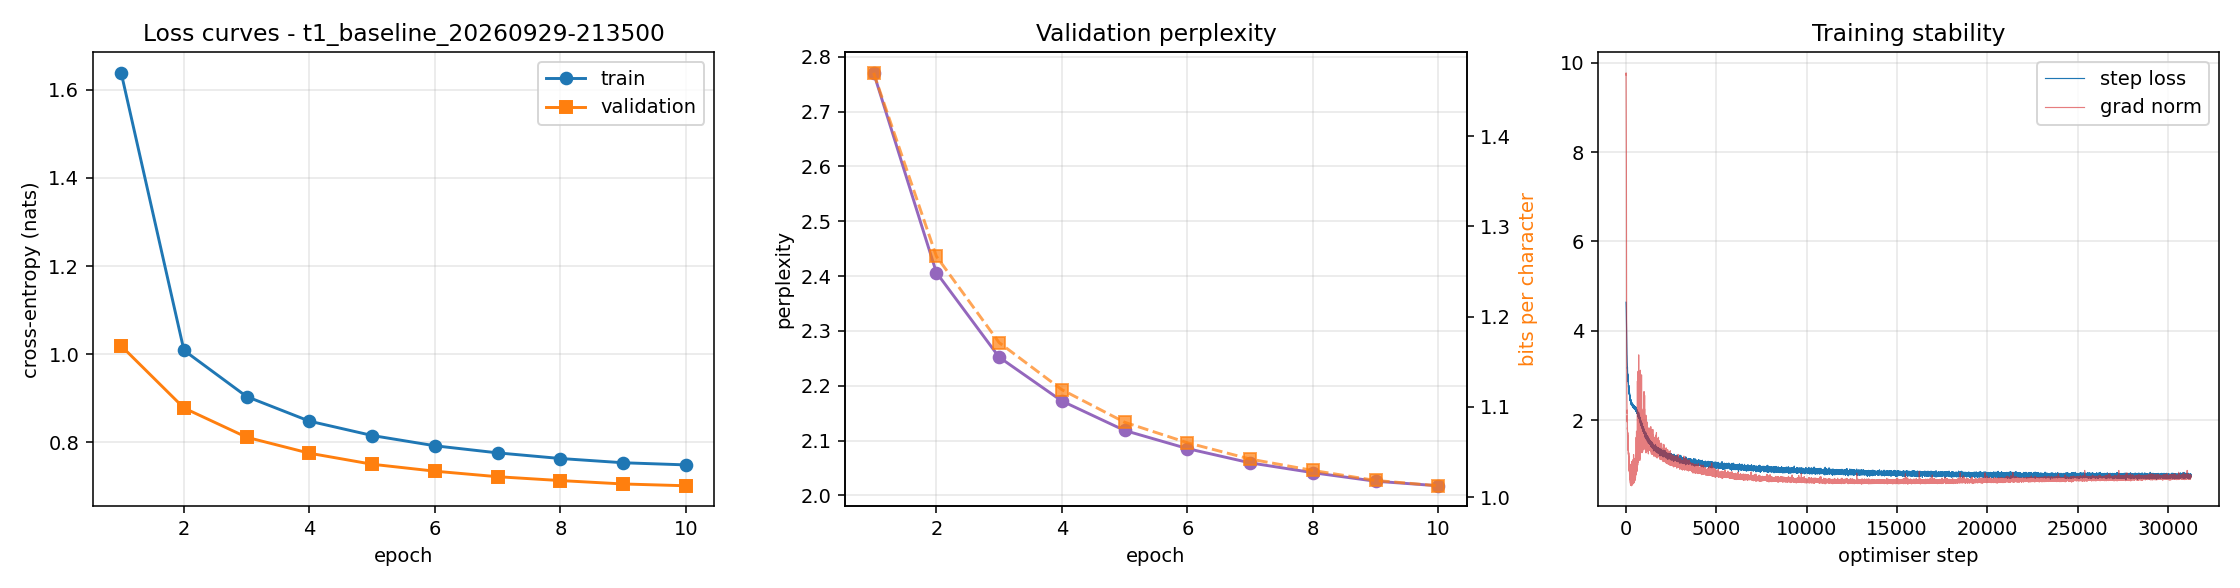

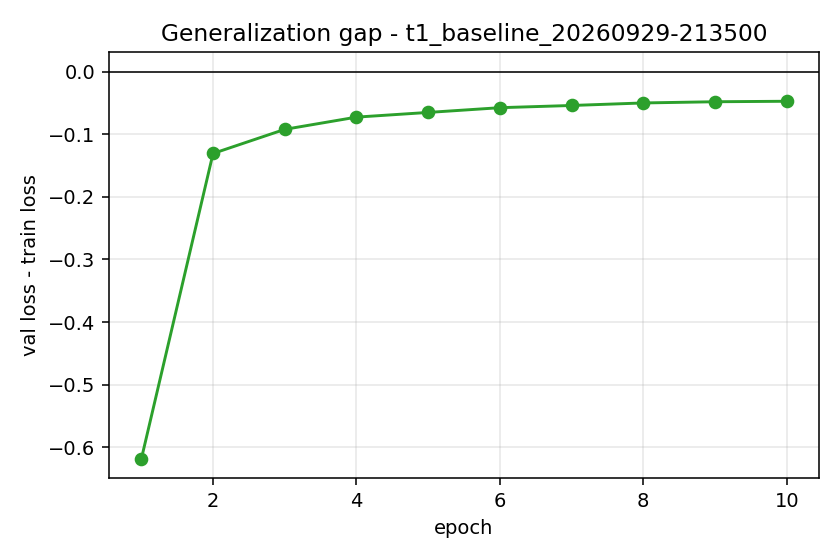

In [9]:
from IPython.display import Image, display
display(Image(filename=str(MEMBER/f'outputs/plots/loss_curves_{RUN}.png')))
display(Image(filename=str(MEMBER/f'outputs/plots/generalization_gap_{RUN}.png')))

In [10]:
gn = hist['grad_norms']; sl = hist['step_losses']
print('steps: %d | grad norm mean %.4f max %.4f' % (len(gn), np.mean(gn), np.max(gn)))
print('NaNs: %d | non-finite losses: %d' % (sum(not np.isfinite(g) for g in gn),
                                            sum(not np.isfinite(l) for l in sl)))
print('validation loss decreased every epoch:', bool((df["loss"].diff().dropna() < 0).all()))

steps: 31250 | grad norm mean 0.7445 max 9.7715
NaNs: 0 | non-finite losses: 0
validation loss decreased every epoch: True


## 5. Text generation

Greedy and temperature sampling, 3 prompts x 3 strategies.

In [11]:
print((MEMBER/f'outputs/samples/samples_{RUN}.txt').read_text(encoding='utf-8')[:1500])

### greedy | prompt='Once upon a time'
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and daddy. They saw a big box of cars and a big box. The box was so happy and the box was so happy to see the box. 
Lily was so happy that she had been so brave and she was so happy to have her box before. She was happy to have her box before and she was proud of herself. 


### temperature=0.8 | prompt='Once upon a time'
Once upon a time there was a little girl named Lily. She loved to play outside in the sunshine.
One day, Lily's mommy asked her to run away. They said she would go out to the sky and have it showed it to her. Lily learned that her mommy and daddy was not happy. But then she saw a big red ball in the sky. She was so sad and lonely.
Lily wanted the ball. She told her mommy about her and wrapped it in her ball. She 

### temperature=1.2 | prompt='Once upon a time'
Once upon a time, there was a

In [12]:
from evaluate import distinct_n, repeated_ngram_rate
import re
blocks = re.split(r'### ', (MEMBER/f'outputs/samples/samples_{RUN}.txt').read_text(encoding='utf-8'))[1:]
groups = {}
for b in blocks:
    head, body = b.split('\n', 1)
    groups.setdefault(head.split(' | ')[0].strip(), []).append(body)
rows = [{'strategy': k, 'distinct_1': distinct_n('\n'.join(v),1), 'distinct_2': distinct_n('\n'.join(v),2),
         'distinct_3': distinct_n('\n'.join(v),3), 'repeated_4gram': repeated_ngram_rate('\n'.join(v),4)}
        for k, v in groups.items()]
pd.DataFrame(rows).round(4)

,strategy,distinct_1,distinct_2,distinct_3,repeated_4gram
0,greedy,0.0263,0.1570,0.2919,0.6129
1,temperature=0.8,0.0303,0.2056,0.4545,0.3743
2,temperature=1.2,0.0367,0.2474,0.5751,0.2262


## 6. All required metrics

Each run writes **both** tables: `metrics_report.csv` in the team-agreed column schema (so my
numbers line up with my teammate's) and `metrics_report_extended.csv` with the columns the team
header omits. Both writers reject a row missing a required column, so neither can silently drop
a metric.

In [13]:
team = pd.read_csv(MEMBER/'metrics_report.csv')          # team-agreed schema
ext  = pd.read_csv(MEMBER/'metrics_report_extended.csv')  # my full set
print('team schema columns: %d | extended: %d' % (len(team.columns), len(ext.columns)))
print('in extended but not in the team header (renames + genuine extras):')
print(' ', sorted(set(ext.columns) - set(team.columns)))
row = ext[ext.run_id == RUN].T
row.columns = ['value']
row

team schema columns: 22 | extended: 25


in extended but not in the team header (renames + genuine extras):
  ['bits_per_char', 'checkpoint_id', 'config_path', 'device', 'model_name', 'param_count', 'top1_next_char_acc', 'total_train_seconds', 'train_loss', 'val_loss']


,value
run_id,t1_baseline_20260929-213500
model_name,t1_baseline
config_path,task1_llm\zoheb_waghu\configs\gpt_baseline.yaml
checkpoint_id,t1_baseline_20260929-213500_best.pt
train_loss,0.69817
val_loss,0.70191
perplexity,2.0176
bits_per_char,1.01264
generalization_gap,0.00373
top1_next_char_acc,0.77742


## 7. Failure analysis (2 marks)

Three cases with the verbatim generated text, failure type and observation:
[failure_analysis.md](failure_analysis.md).

1. **Phrase-level repetition loop** under greedy - repeated-4-gram rate 0.6129 vs 0.2262 at temperature 1.2
2. **High-temperature word and semantic corruption** - `loved very melty`, `hidden aboven the ground`
3. **Story-boundary confusion** - the model abandons the current story and restarts with `Once upon a time`

Greedy decoding is locally fluent but repetitive; temperature 1.2 improves diversity while
admitting invalid words and incoherent continuations. The write-up uses only the RTX 4090
run's `20260929-213500` samples.

Full write-up and design justification: [results.md](results.md).